## Frank2D GPU 
### Description
This algorithm is the GPU version of the CPU Frankenstein2D optimized algorithm version.


#### Imports 

In [2]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time


import cupy as cp
from cupy import cublas
from cupy._core import _dtype
from cupy.cuda import device
from cupy_backends.cuda.libs import cublas as _cublas
from cupyx.scipy.sparse import _csr
from cupyx.scipy.sparse.linalg import _interface
from cupyx.scipy.sparse import csr_matrix
from cupyx.scipy.sparse.linalg import LinearOperator
from cupy_backends.cuda.libs import cusparse as _cusparse
from cupyx import cusparse

current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
from plot import Plot
from fitting import IterativeSolverMethod

from preprocess_vis_gpu import Gridding_GPU
from geometry_gpu import Geometry_GPU
from fourier2d_gpu import FourierTransform2D_GPU

#### Functions

#### BICGM


In [3]:
def _get_atol_rtol(name, b_norm, atol=0., rtol=1e-5):
    """
    A helper function to handle tolerance normalization
    """
    if atol == 'legacy' or atol is None or atol < 0:
        msg = (f"'scipy.sparse.linalg.{name}' called with invalid `atol`={atol}; "
            "if set, `atol` must be a real, non-negative number.")
        raise ValueError(msg)
    
    print(f'         * rtol: {float(rtol)}')
    
    atol = max(float(atol), float(rtol) * float(b_norm))
    print(f'         * final tolerance : {atol}')
    
    return atol, rtol

In [4]:
def _make_fast_matvec(A):
    if _csr.isspmatrix_csr(A) and cusparse.check_availability('spmv'):
        handle = device.get_cusparse_handle()
        op_a = _cusparse.CUSPARSE_OPERATION_NON_TRANSPOSE
        alpha = numpy.array(1.0, A.dtype)
        beta = numpy.array(0.0, A.dtype)
        cuda_dtype = _dtype.to_cuda_dtype(A.dtype)
        alg = _cusparse.CUSPARSE_MV_ALG_DEFAULT
        x = cp.empty((A.shape[0],), dtype=A.dtype)
        y = cp.empty((A.shape[0],), dtype=A.dtype)
        desc_A = cusparse.SpMatDescriptor.create(A)
        desc_x = cusparse.DnVecDescriptor.create(x)
        desc_y = cusparse.DnVecDescriptor.create(y)
        buff_size = _cusparse.spMV_bufferSize(
            handle, op_a, alpha.ctypes.data, desc_A.desc, desc_x.desc,
            beta.ctypes.data, desc_y.desc, cuda_dtype, alg)
        buff = cp.empty(buff_size, cp.int8)
        del x, desc_x, y, desc_y

        def matvec(x):
            y = cp.empty_like(x)
            desc_x = cusparse.DnVecDescriptor.create(x)
            desc_y = cusparse.DnVecDescriptor.create(y)
            _cusparse.spMV(
                handle, op_a, alpha.ctypes.data, desc_A.desc, desc_x.desc,
                beta.ctypes.data, desc_y.desc, cuda_dtype, alg, buff.data.ptr)
            return y

        return matvec
    return None

In [5]:
def _make_system(A, M, x0, b):
    """Forza un sistema Ax = b complejo (usa complex64 siempre)."""
    target_dtype = cp.complex64

    fast_matvec = _make_fast_matvec(A)
    A = _interface.aslinearoperator(A)

    if fast_matvec is not None:
        A = _interface.LinearOperator(A.shape, matvec=fast_matvec,
                                      rmatvec=A.rmatvec, dtype=target_dtype)
    else:
        A = _interface.LinearOperator(A.shape, matvec=A.matvec,
                                      rmatvec=A.rmatvec, dtype=target_dtype)

    if A.shape[0] != A.shape[1]:
        raise ValueError(f'expected square matrix (shape: {A.shape})')

    n = A.shape[0]
    if not (b.shape == (n,) or b.shape == (n, 1)):
        raise ValueError('b has incompatible dimensions')
    b = b.astype(target_dtype).ravel()

    if x0 is None:
        x = cp.zeros((n,), dtype=target_dtype)
    else:
        if not (x0.shape == (n,) or x0.shape == (n, 1)):
            raise ValueError('x0 has incompatible dimensions')
        x = x0.astype(target_dtype).ravel()

    if M is None:
        M = _interface.IdentityOperator(shape=A.shape, dtype=target_dtype)
    else:
        fast_matvec = _make_fast_matvec(M)
        M = _interface.aslinearoperator(M)
        if fast_matvec is not None:
            M = _interface.LinearOperator(M.shape, matvec=fast_matvec,
                                          rmatvec=M.rmatvec, dtype=target_dtype)
        else:
            M = _interface.LinearOperator(M.shape, matvec=M.matvec,
                                          rmatvec=M.rmatvec, dtype=target_dtype)
        if A.shape != M.shape:
            raise ValueError('matrix and preconditioner have different shapes')

    return A, M, x, b

In [6]:
def bicgstab_cupy(A, b, x0=None, tol=1e-7, maxiter=None, M=None, callback=None, atol=None):
    """Use BiConjugate Gradient Stabilized iteration to solve ``Ax = b`` using CuPy."""
    print("     * BICGSTAB (CuPy version)")
    A, M, x, b = _make_system(A, M, x0, b)
    matvec = A.matvec
    psolve = M.matvec

    n = A.shape[0]
    if maxiter is None:
        maxiter = n * 10
    if n == 0:
        return cp.empty_like(b), 0

    b_norm = cublas.nrm2(b)
    if b_norm == 0:
        return b, 0

    if atol is None:
        atol = tol * float(b_norm)
    else:
        atol = max(float(atol), tol * float(b_norm))

    r = b - matvec(x)
    rtilde = r.copy()
    rho_prev = alpha = omega = 1.0
    v = p = cp.zeros_like(b)
    iters = 0

    while iters < maxiter:
        print(".... iteration: ", iters)
        rho = cublas.dotc(rtilde, r)
        if cp.abs(rho) < 1e-30:  # rho breakdown
            return x, -10

        if iters == 0:
            p = r.copy()
        else:
            if cp.abs(omega) < 1e-30:  # omega breakdown
                return x, -11
            beta = (rho / rho_prev) * (alpha / omega)
            p = r + beta * (p - omega * v)

        phat = psolve(p)
        v = matvec(phat)
        rv = cublas.dotc(rtilde, v)
        if rv == 0:
            return x, -12

        alpha = rho / rv
        s = r - alpha * v

        if cublas.nrm2(s) < atol:
            x += alpha * phat
            break

        shat = psolve(s)
        t = matvec(shat)
        tt = cublas.dotc(t, t)
        if tt == 0:
            return x, -13

        omega = cublas.dotc(t, s) / tt
        x += alpha * phat + omega * shat
        r = s - omega * t
        rho_prev = rho
        iters += 1

        if callback is not None:
            callback(x)

        act_tol = cublas.nrm2(r)
        print("                        -> actual tol: ", act_tol, "vs ", str(atol))
        if act_tol <= atol:
            break

    info = 0 if cublas.nrm2(r) <= atol else iters
    return x, info

####  Functions for optimization

In [7]:
def linear_operator(A, size):
    def dot_product(x):
        return A.dot(x)

    return LinearOperator(size, matvec=dot_product)

In [8]:
def P_k(r, k):
    if k == 0:
        return cp.ones_like(r)  # P_0(r) = 1
    elif k == 1:
        return 4*r +1  # P_1(r) = 4r + 1
    elif k == 2:
        return (35/3)*r**2 +6*r + 1  # P_2(r) = 35r^2 + 18r + 3

In [9]:
def kernel_row(u, v, i, min_freq, u2 = None, v2 = None, m = -0.33, c = -0.1, l = 1e5):
    def power_spectrum(q, m, c):
        if not cp.isscalar(q):  
            q[q == 0] = min_freq
        elif q == 0:
            q = min_freq
        return (q**m)*cp.exp(c)
    
    j, k = 4, 1
    H = 2*1.897367*l

    q = cp.hypot(u, v)
    power_spectrum_q1 = power_spectrum(q, m, c)
    uh = u/H
    vh = v/H

    q2 = uh2 = vh2 =  None

    if isinstance(u2, cp.ndarray):
        q2 = cp.hypot(u2[i], v2[i])
        uh2 = u2[i]/H
        vh2 = v2[i]/H
    else:
        q2 = q[i]
        uh2 = uh[i]
        vh2 = vh[i]

    amp = cp.sqrt(power_spectrum_q1 * power_spectrum(q2, m, c))
    
    r_normalized = cp.sqrt((uh-uh2)**2 + (vh-vh2)**2)
    factor = (1 - r_normalized)**j
    factor[r_normalized > 1] = 0

    return amp * factor * P_k(r_normalized, k)

In [10]:
def create_sparse_kernel(kernel_function, u, v, min_freq, u2 = None, v2 = None ):
    if isinstance(u2, cp.ndarray):
        size1 = len(u2)
        size2 = len(u)
    else:
        size1 = size2 = len(u)

    data = cp.array([], dtype=cp.float64)
    indices = cp.array([], dtype=cp.int64)
    indptr = cp.zeros(size1 + 1, dtype=cp.int64)

    for i in range(size1):
        row = kernel_function(u, v, i, min_freq, u2=u2, v2=v2) if isinstance(u2, cp.ndarray) else kernel_function(u, v, i, min_freq)
        
        non_zero_indices = cp.nonzero(row)[0]
        kernel_values = row[non_zero_indices]

        data = cp.concatenate((data, kernel_values))
        indices = cp.concatenate((indices, non_zero_indices))
        indptr[i + 1] = data.size

    size = (size1, size2)
    kernel_csr = csr_matrix((data, indices, indptr), shape=size)
    kernel_csr = linear_operator(kernel_csr, size)

    return kernel_csr

In [11]:
def create_sparse_system_data(u_gridded_data, v_gridded_data, vis_gridded_data, weights_gridded_data, min_freq):
    N_data = vis_gridded_data.shape[0]
    
    data_A = cp.array([], dtype=cp.float64)
    indices_A = cp.array([], dtype=cp.int64)
    indptr_A = cp.zeros(N_data + 1, dtype=cp.int64)

    data_Aprecond = cp.array([], dtype=cp.float64)
    indices_Aprecond = cp.array([], dtype=cp.int64)
    indptr_Aprecond = cp.zeros(N_data + 1, dtype=cp.int64)

    for i in range(N_data):  
        row = kernel_row(u_gridded_data, v_gridded_data, i, min_freq)
        non_zero_indices = cp.nonzero(row)[0]
        non_zero_values = row[non_zero_indices]
        Nm1_S_values = non_zero_values * weights_gridded_data[i]

        # A
        diagonal_pos = cp.where(non_zero_indices == i)[0][0]
        Nm1_S_values[diagonal_pos] += 1
        diag_value = Nm1_S_values[diagonal_pos]

        # Concatenate new values into CuPy arrays
        data_A = cp.concatenate((data_A, Nm1_S_values))
        indices_A = cp.concatenate((indices_A, non_zero_indices))
        indptr_A[i + 1] = data_A.size

        # Preconditioner of A
        data_Aprecond = cp.concatenate((data_Aprecond, cp.array([diag_value**(-1)])))
        indices_Aprecond = cp.concatenate((indices_Aprecond, cp.array([i])))
        indptr_Aprecond[i + 1] = data_Aprecond.size

    A_csr = csr_matrix((data_A, indices_A, indptr_A), shape=(N_data, N_data))
    A_precond_csr = csr_matrix((data_Aprecond, indices_Aprecond, indptr_Aprecond), shape=(N_data, N_data))

    A = linear_operator(A_csr, (N_data, N_data))
    A_precond = linear_operator(A_precond_csr, (N_data, N_data))

    b = weights_gridded_data * vis_gridded_data

    return A, A_precond, b

In [12]:
import cupy as cp
from cupyx.scipy.sparse import csr_matrix

def create_sparse_system_data(u_gridded_data, v_gridded_data, vis_gridded_data, weights_gridded_data, min_freq, N_data):
    # Initialize as CuPy arrays instead of Python lists
    data_A = cp.array([], dtype=cp.float32)
    indices_A = cp.array([], dtype=cp.int32)
    indptr_A = cp.zeros(N_data + 1, dtype=cp.int32)

    data_Aprecond = cp.array([], dtype=cp.float32)
    indices_Aprecond = cp.array([], dtype=cp.int32)
    indptr_Aprecond = cp.zeros(N_data + 1, dtype=cp.int32)

    weights = weights_gridded_data  # Assuming this is already a CuPy array

    for i in range(N_data):  
        row = kernel_row(u_gridded_data, v_gridded_data, i, min_freq)
        non_zero_indices = cp.nonzero(row)[0]
        non_zero_values = row[non_zero_indices]

        Nm1_S_values = non_zero_values * weights[i]

        # A
        diagonal_pos = cp.where(non_zero_indices == i)[0][0]
        Nm1_S_values[diagonal_pos] += 1
        diag_value = Nm1_S_values[diagonal_pos]

        # Concatenate new values into CuPy arrays
        data_A = cp.concatenate((data_A, Nm1_S_values))
        indices_A = cp.concatenate((indices_A, non_zero_indices))
        indptr_A[i + 1] = data_A.size

        # Preconditioner of A
        data_Aprecond = cp.concatenate((data_Aprecond, cp.array([diag_value**(-1)])))
        indices_Aprecond = cp.concatenate((indices_Aprecond, cp.array([i])))
        indptr_Aprecond[i + 1] = data_Aprecond.size

    # Create sparse matrices in CuPy
    A_csr = csr_matrix((data_A, indices_A, indptr_A), shape=(N_data, N_data))
    A_precond_csr = csr_matrix((data_Aprecond, indices_Aprecond, indptr_Aprecond), shape=(N_data, N_data))

    # Convert to linear operators (assuming linear_operator is CuPy-compatible)
    A = linear_operator(A_csr, (N_data, N_data))
    A_precond = linear_operator(A_precond_csr, (N_data, N_data))

    # Compute b on the GPU
    b = weights * vis_gridded_data  # Ensure vis_gridded_data is also CuPy

    return A, A_precond, b

### Frank2D GPU

**Params for algorithm: N, u_gridded, v_gridded, Visibilities_gridded, Weights_gridded**

In [19]:
def Frank2D_GPU_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded, plot = True):
    input = weights_gridded.reshape(N, N)
    data_index = cp.argwhere(input.flatten() != 0)
    no_data_index = cp.argwhere(input.flatten() == 0) 

    # data
    u_gridded_data = u_gridded[data_index].flatten()
    v_gridded_data = v_gridded[data_index].flatten()
    vis_gridded_data  = vis_gridded[data_index].flatten()
    weights_gridded_data = weights_gridded[data_index].flatten()

    # no data or data with weights == 0.
    u_gridded_no_data = u_gridded[no_data_index].flatten()
    v_gridded_no_data = v_gridded[no_data_index].flatten()
    vis_gridded_no_data  = vis_gridded[no_data_index].flatten()
    weights_gridded_no_data = weights_gridded[no_data_index].flatten()

    #  We intend to solve now:  (I + N^{-1} S_{11})  V* = N^{-1} V_{data} with CGM
    min_freq = cp.sort(cp.abs(cp.unique(v_gridded_data)))[1]
    N_data = vis_gridded_data.shape[0]


    print("------> Creating linear operators")
    start_time = time.time()
    S11_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data, min_freq)
    S12_T_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data, min_freq, u2 = u_gridded_no_data, v2 = v_gridded_no_data)
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
    print("---------------------------------")

    print("------> Creating sparse system")
    start_time = time.time()
    params = [u_gridded_data, v_gridded_data, vis_gridded_data, weights_gridded_data, min_freq, N_data]
    A_opt, A_precond_opt, b_opt = create_sparse_system_data(*params)
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
    print("---------------------------------")

    print("------> Running CGM")
    start_time = time.time()
    x_data, info = bicgstab_cupy(A_opt, b_opt, M = A_precond_opt, tol = 1e-12)
    C_ = x_data
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
    print("---------------------------------")
    
    print("------> CGM converged?  ", info == 0)
    fit_correctly = cp.allclose(A_opt.matvec(C_), b_opt)
    print("              --> Fit correctly?  ", fit_correctly)
    if fit_correctly:
        print("                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!")
    print("---------------------------------")
    

    def recovering_sol(C):
        V_1_m = S11_linearOp.matvec(C)
        V_2_m = S12_T_linearOp.matvec(C)
        
        V_m = cp.zeros((N, N), dtype = 'c16')
        
        data_coords = cp.unravel_index(data_index.flatten(), (N, N))
        no_data_coords = cp.unravel_index(no_data_index.flatten(), (N, N))
        
        V_m[data_coords] = V_1_m
        V_m[no_data_coords] = V_2_m
    
        u_m = cp.zeros((N, N))
        v_m = cp.zeros((N, N))
        
        u_m[data_coords] = u_gridded_data
        u_m[no_data_coords] = u_gridded_no_data
        
        v_m[data_coords] = v_gridded_data
        v_m[no_data_coords] = v_gridded_no_data
        
        return V_m

    V_m = recovering_sol(C_)

    if plot:
        import numpy as np
        u_gridded_np = u_gridded.get()
        v_gridded_np = v_gridded.get()
        V_m_np = V_m.get()
        
        plt.pcolormesh(np.fft.fftshift(v_gridded_np.reshape(N, N)), np.fft.fftshift(u_gridded_np).reshape(N,N), np.log(np.abs(np.fft.fftshift(V_m_np))), cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [ $\lambda$]')
        plt.ylabel(r'v [ $\lambda$]')
        plt.gca().set_aspect('equal') 
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=15)
        plt.title(r'log|$Vis_{model}$| from matrix mult in GPU')
        plt.show()

    

### Testing

In [14]:
disk_name = 'AS209 1mm'

# Huang 2018 
inc = 34.97
pa = 85.76
dra = 1.9e-3
ddec = -2.5e-3
Rout = 3 #arcsecs

# UVtable
dir = "./../../data/"
data_file = dir +'AS209_continuum_prom_1chan_30s_keepflagsFalse.txt'

 # load data
u, v, Re, Imag, Weights = cp.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

In [15]:
N = 100

In [16]:
Geom = Geometry_GPU(inc, pa, dra, ddec)
Rmax = Rout/rad_to_arcsec
FT = FourierTransform2D_GPU(Rmax, N, Geom)
Grid = Gridding_GPU(N, Rmax, FT, Geom)

In [17]:
u_gridded, v_gridded, vis_gridded, weights_gridded = Grid.run(u, v, Vis, Weights)

Enforcing Hermitian symmetry...


------> Creating linear operators
  --> time = 0.75  min |  45.25 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.72  min |  43.36 seconds
---------------------------------
------> Running CGM
     * BICGSTAB (CuPy version)
.... iteration:  0
                        -> actual tol:  52448813.24652442 vs  0.000246737344
.... iteration:  1
                        -> actual tol:  36140377.728419065 vs  0.000246737344
.... iteration:  2
                        -> actual tol:  26621087.1601732 vs  0.000246737344
.... iteration:  3
                        -> actual tol:  18676821.392351594 vs  0.000246737344
.... iteration:  4
                        -> actual tol:  12163043.614418352 vs  0.000246737344
.... iteration:  5
                        -> actual tol:  9927820.436341587 vs  0.000246737344
.... iteration:  6
                        -> actual tol:  8888833.570061002 vs  0.000246737344
.... iteration:  7
                        -> actual tol:  904

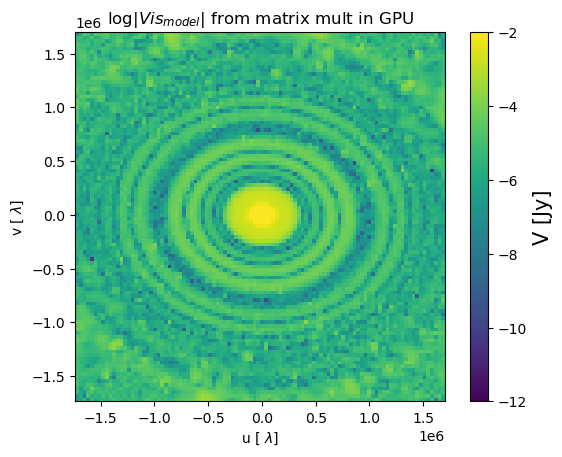

In [20]:
sol = Frank2D_GPU_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded)

**WORKS**

### Let's see the gridded vis.

In [ ]:
u_gridded_to_np = u_gridded.get()
v_gridded_to_np = v_gridded.get()
vis_gridded_to_np = vis_gridded.get()

x_labels = np.fft.fftshift(FT._u.get()/1e6)
y_labels = np.fft.fftshift(FT._v.get()/1e6)

num_ticks = 5
x_ticks_to_show = np.linspace(0, len(x_labels) - 1, num_ticks).astype(int)
y_ticks_to_show = np.linspace(0, len(y_labels) - 1, num_ticks).astype(int)

def format_labels(x):
    return f"{int(x):.1f}" if abs(x) > 1e-8 else "0"

In [ ]:
plt.imshow(np.log(np.abs(np.fft.fftshift(vis_gridded_to_np.reshape(FT._Nx, FT._Ny)))), origin='lower', vmin=-15, vmax=-2)
plt.xticks(ticks=x_ticks_to_show, labels=[format_labels(x) for x in np.array(x_labels)[x_ticks_to_show]])
plt.yticks(ticks=y_ticks_to_show, labels=[format_labels(y) for y in np.array(y_labels)[y_ticks_to_show]])
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)